# GDP Analysis - Assignment

### 1. GDP Analysis - Dataset Walkthrough

In [1]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("gdp_data.csv")

# Show first 5 rows
df.head()

,country_name,country_code,year,value,Prev_Year_GDP,GDP_Growth_%
0,Afghanistan,AFG,1960,537777811.1,NaN,NaN
1,Afghanistan,AFG,1961,548888895.6,537777811.1,2.066111
2,Afghanistan,AFG,1962,546666677.8,548888895.6,-0.404857
3,Afghanistan,AFG,1963,751111191.1,546666677.8,37.398386
4,Afghanistan,AFG,1964,800000044.4,751111191.1,6.508870


##### Calculate gdp grouth

In [2]:
# Calculate GDP Growth Rate per country
df['GDP_Growth_%'] = df.groupby('country_name')['value'].pct_change() * 100

# Display results
print(df.head(20))


   country_name country_code  year         value  Prev_Year_GDP  GDP_Growth_%
0   Afghanistan          AFG  1960  5.377778e+08            NaN           NaN
1   Afghanistan          AFG  1961  5.488889e+08   5.377778e+08      2.066111
2   Afghanistan          AFG  1962  5.466667e+08   5.488889e+08     -0.404857
3   Afghanistan          AFG  1963  7.511112e+08   5.466667e+08     37.398386
4   Afghanistan          AFG  1964  8.000000e+08   7.511112e+08      6.508870
5   Afghanistan          AFG  1965  1.006667e+09   8.000000e+08     25.833323
6   Afghanistan          AFG  1966  1.400000e+09   1.006667e+09     39.072848
7   Afghanistan          AFG  1967  1.673333e+09   1.400000e+09     19.523818
8   Afghanistan          AFG  1968  1.373333e+09   1.673333e+09    -17.928289
9   Afghanistan          AFG  1969  1.408889e+09   1.373333e+09      2.588997
10  Afghanistan          AFG  1970  1.748887e+09   1.408889e+09     24.132326
11  Afghanistan          AFG  1971  1.831109e+09   1.748887e+09 

##### Visualize GDP trend

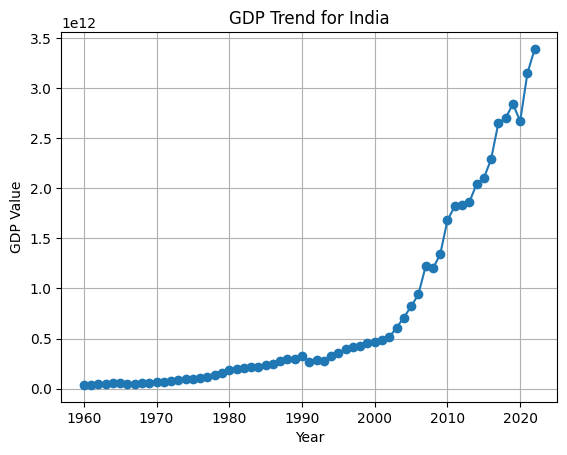

In [3]:
import matplotlib.pyplot as plt

ind = df[df['country_name'] == 'India']

plt.plot(ind['year'], ind['value'], marker='o')
plt.title('GDP Trend for India')
plt.xlabel('Year')
plt.ylabel('GDP Value')
plt.grid()
plt.show()

#### 1) How many unique Countries Data we're having in the dataset?

In [4]:
df['country_name'].nunique()

262

### 2. GDP Analysis - GDP Growth of a Country

##### Load the dataset and identify the GDP values for consecutive years.

In [5]:
# Create a new column for previous year's GDP
df["Prev_Year_GDP"] = df.groupby("country_name")["value"].shift(1)
df.head(5)

,country_name,country_code,year,value,Prev_Year_GDP,GDP_Growth_%
0,Afghanistan,AFG,1960,537777811.1,NaN,NaN
1,Afghanistan,AFG,1961,548888895.6,537777811.1,2.066111
2,Afghanistan,AFG,1962,546666677.8,548888895.6,-0.404857
3,Afghanistan,AFG,1963,751111191.1,546666677.8,37.398386
4,Afghanistan,AFG,1964,800000044.4,751111191.1,6.508870


##### Add the calculated GDP growth as a new column to the dataset.

In [6]:
df.to_csv("gdp_data.csv", index=False)

###  3. GDP Analysis - GDP Growth on Whole Dataset

##### Iterate through the dataset:

In [8]:
countries = df['country_name'].unique()
df['GDP_Growth_%_Loop'] = None

for country in countries:
    country_data = df[df['country_name'] == country].reset_index()
    
    for i in range(1, len(country_data)):
        current_gdp = country_data.loc[i, 'value']
        previous_gdp = country_data.loc[i - 1, 'value']
        
        grouth_current = ((current_gdp - previous_gdp) / previous_gdp) * 100
        
        df.loc[(df['country_name'] == country) & (df['year'] == country_data.loc[i, "year"]), "GDP_Growth_%_Loop"] = grouth_current
        
df.head()

,country_name,country_code,year,value,Prev_Year_GDP,GDP_Growth_%,GDP_Growth_%_Loop
0,Afghanistan,AFG,1960,537777811.1,NaN,NaN,None
1,Afghanistan,AFG,1961,548888895.6,537777811.1,2.066111,2.066111
2,Afghanistan,AFG,1962,546666677.8,548888895.6,-0.404857,-0.404857
3,Afghanistan,AFG,1963,751111191.1,546666677.8,37.398386,37.398386
4,Afghanistan,AFG,1964,800000044.4,751111191.1,6.508870,6.50887
